In [29]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D

In [31]:
dataset_path = "image recognization/data/dataset"

In [32]:
import os
os.listdir(dataset_path)


['Ahegao', 'Angry', 'Happy', 'Neutral', 'Sad', 'Surprise']

In [33]:
df = pd.read_csv(r"image recognization/data/data.csv")
df.head()

,Unnamed: 0,path,label
0,0,Surprise/1bd930d6a1c717c11be33db74823f661cb53f...,Surprise
1,1,Surprise/cropped_emotions.100096~12fffff.png,Surprise
2,2,Surprise/0df0e470e33093f5b72a8197fa209d684032c...,Surprise
3,3,Surprise/cropped_emotions.260779~12fffff.png,Surprise
4,4,Surprise/cropped_emotions.263616~12fffff.png,Surprise


In [51]:
from PIL import Image
import numpy as np
import os

IMAGE_SIZE = (28, 28)

X = []
y = []

for index, row in df.iterrows():
    image_path = os.path.join(dataset_path, row['path'])
    label = row['label']

    try:
        img = Image.open(image_path)

        img = img.convert('L')

        img = img.resize(IMAGE_SIZE)

        img_array = np.array(img)
        img_array = img_array / 255.0  # Normalize to [0, 1]

        img_array = np.expand_dims(img_array, axis=-1)

        X.append(img_array)
        y.append(label)

    except FileNotFoundError:
        print(f"Warning: Image not found at {image_path}. Skipping.")
    except Exception as e:
        print(f"Error processing image {image_path}: {e}. Skipping.")

X = np.array(X)
y = np.array(y)

In [52]:
X_flattened = X.reshape(X.shape[0], -1)
pixel_cols = [f'pixel_{i}' for i in range(X_flattened.shape[1])]
image_df = pd.DataFrame(X_flattened, columns=pixel_cols)
image_label_df = pd.concat([image_df, pd.Series(y, name='label')], axis=1)
display(image_label_df.head())

print(X.shape, y.shape)


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783,label
0,0.658824,0.584314,0.623529,0.380392,0.266667,0.290196,0.372549,0.364706,0.364706,0.384314,...,0.674510,0.290196,0.180392,0.231373,0.172549,0.250980,0.266667,0.231373,0.117647,Surprise
1,0.345098,0.396078,0.384314,0.352941,0.337255,0.235294,0.137255,0.207843,0.349020,0.372549,...,0.003922,0.023529,0.054902,0.054902,0.094118,0.149020,0.231373,0.333333,0.392157,Surprise
2,0.384314,0.388235,0.403922,0.360784,0.160784,0.137255,0.184314,0.192157,0.196078,0.168627,...,0.458824,0.282353,0.721569,0.764706,0.690196,0.690196,0.666667,0.576471,0.066667,Surprise
3,0.580392,0.447059,0.372549,0.360784,0.356863,0.329412,0.333333,0.400000,0.454902,0.470588,...,0.631373,0.647059,0.631373,0.400000,0.196078,0.133333,0.129412,0.168627,0.188235,Surprise
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.435294,0.341176,0.231373,0.176471,0.247059,0.239216,0.231373,0.219608,0.207843,Surprise


(15453, 28, 28, 1) (15453,)


In [53]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
image_label_df['label'] = le.fit_transform(image_label_df['label'])

In [54]:
image_label_df['label'].value_counts()

label
3    4027
4    3934
2    3740
1    1313
5    1234
0    1205
Name: count, dtype: int64

In [55]:
x = image_label_df.drop(['label'], axis=1)
y = image_label_df['label']

In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)


In [57]:
# now convert each row to image of matrix
X_train_img = X_train.values.reshape(-1, 28, 28, 1)
X_test_img = X_test.values.reshape(-1, 28, 28, 1)


In [58]:
# scaling labels so that it lies between 0 and 1
from tensorflow.keras.utils import to_categorical
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

In [59]:
#ANN
ann = Sequential([
    Flatten(input_shape=(28, 28, 1)),
    Dense(128, activation='relu', input_shape=(784,)),
    Dense(64, activation='relu'),
    Dense(6, activation='softmax')
])

In [60]:
ann.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [61]:
history = ann.fit(X_train_img,y_train_cat,epochs=50,batch_size=32,verbose=1,validation_data=(X_test_img,y_test_cat))

Epoch 1/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3236 - loss: 1.5505 - val_accuracy: 0.3491 - val_loss: 1.4887
Epoch 2/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4104 - loss: 1.4030 - val_accuracy: 0.4267 - val_loss: 1.3513
Epoch 3/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4397 - loss: 1.3367 - val_accuracy: 0.4662 - val_loss: 1.3078
Epoch 4/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4623 - loss: 1.3063 - val_accuracy: 0.4549 - val_loss: 1.3248
Epoch 5/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4741 - loss: 1.2764 - val_accuracy: 0.4710 - val_loss: 1.2786
Epoch 6/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4927 - loss: 1.2415 - val_accuracy: 0.4808 - val_loss: 1.2682
Epoch 7/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4986 - loss: 1.2276 - val_accuracy: 0.4368 - val_loss: 1.3668
Epoch 8/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5047 - loss: 1.2089 - val_accuracy: 0.

In [62]:
ann_acuuracy = ann.evaluate(X_test_img,y_test_cat,verbose=0)[1]

In [63]:
ann_acuuracy*100 

51.73082947731018

In [64]:
import tensorflow as tf

In [65]:
#CNN
cnn = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)), # added L2 regularization
    Dropout(0.5),
    Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),  # added L2 regularization
    Dropout(0.5), 
    Dense(6, activation='softmax')
])

In [66]:
cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [67]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


In [68]:
cnn.fit(X_train_img,y_train_cat,epochs=50,batch_size=32,verbose=1,validation_data=(X_test_img,y_test_cat), callbacks=[early_stopping])

Epoch 1/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.2809 - loss: 1.7047 - val_accuracy: 0.3785 - val_loss: 1.4951
Epoch 2/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.4003 - loss: 1.4614 - val_accuracy: 0.5144 - val_loss: 1.3026
Epoch 3/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.4853 - loss: 1.3177 - val_accuracy: 0.5422 - val_loss: 1.1759
Epoch 4/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.5202 - loss: 1.2517 - val_accuracy: 0.5629 - val_loss: 1.1640
Epoch 5/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5413 - loss: 1.2029 - val_accuracy: 0.5895 - val_loss: 1.0993
Epoch 6/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5614 - loss: 1.1629 - val_accuracy: 0.5823 - val_loss: 1.0960
Epoch 7/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5751 - loss: 1.1450 - val_accuracy: 0.5933 - val_loss: 1.0773
Epoch 8/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5861 - loss: 1.1188 - val_accu

In [69]:
model_filename = 'emotion_recognition_cnn_model.keras'
cnn.save(model_filename)

In [70]:
loaded_model = tf.keras.models.load_model('emotion_recognition_cnn_model.keras')

loss, accuracy = loaded_model.evaluate(X_test_img, y_test_cat, verbose=0)
print(f"model accuracy on test data: {accuracy*100:.2f}%")

model accuracy on test data: 66.94%


In [71]:

print(loaded_model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 697,172 (2.66 MB)

 Trainable params: 232,390 (907.77 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 464,782 (1.77 MB)

None


In [72]:
cnn.evaluate(X_test_img,y_test_cat,verbose=0)[1]*100

66.93626642227173

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.75      0.79       259
           1       0.57      0.57      0.57       248
           2       0.83      0.82      0.83       742
           3       0.58      0.70      0.63       789
           4       0.63      0.54      0.58       808
           5       0.60      0.54      0.57       245

    accuracy                           0.67      3091
   macro avg       0.67      0.65      0.66      3091
weighted avg       0.67      0.67      0.67      3091



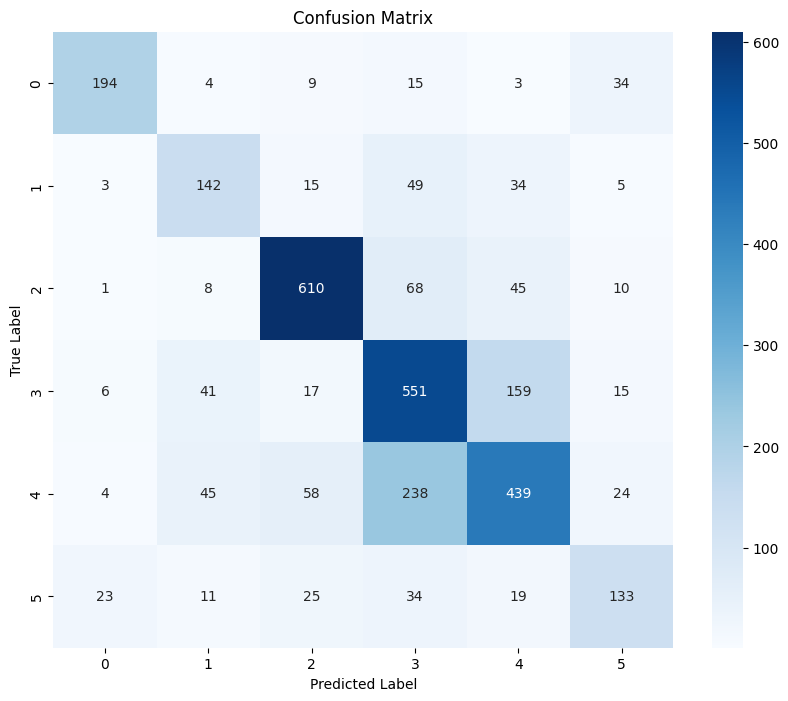

In [74]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf 


loaded_model = tf.keras.models.load_model('emotion_recognition_cnn_model.keras')

y_pred_cat = loaded_model.predict(X_test_img,verbose=0)
y_pred = np.argmax(y_pred_cat, axis=1)

# Convert y_test_cat back to original labels for comparison if needed
y_true = np.argmax(y_test_cat, axis=1)

# Generate classification report
print("Classification Report:")
print(classification_report(y_true, y_pred))

# Generate confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

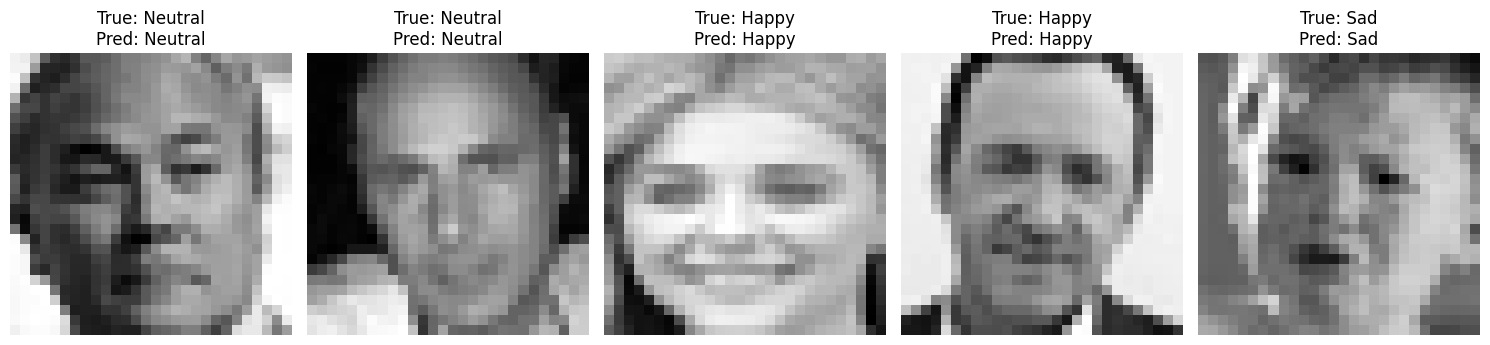

In [80]:
import random
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf

le = LabelEncoder()
le.fit(df['label'])

class_names = le.classes_

loaded_model = tf.keras.models.load_model('emotion_recognition_cnn_model.keras')

num_samples = 5
random_indices = random.sample(range(len(X_test_img)), num_samples)

sampled_images = X_test_img[random_indices]
sampled_true_labels = np.argmax(y_test_cat[random_indices], axis=1)

sampled_predictions_cat = loaded_model.predict(sampled_images,verbose=0)
sampled_predicted_labels = np.argmax(sampled_predictions_cat, axis=1)

plt.figure(figsize=(15, 5))
for i in range(num_samples):
    plt.subplot(1, num_samples, i + 1)
    plt.imshow(sampled_images[i].reshape(28, 28), cmap='gray')
    plt.title(f"True: {class_names[sampled_true_labels[i]]}\nPred: {class_names[sampled_predicted_labels[i]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()